In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron

In [2]:
iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 0) # Iris setosa

per_clf = Perceptron(random_state=42)
per_clf.fit(X, y)

Perceptron(random_state=42)

In [3]:
X_new = [[2, 0.5], [3, 1]]
y_pred = per_clf.predict(X_new)
y_pred

array([ True, False])

In [4]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [5]:
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [6]:
housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, random_state=42)

In [7]:
mlp_reg = MLPRegressor(hidden_layer_sizes=[50, 50, 50], random_state=42)
pipeline = make_pipeline(StandardScaler(), mlp_reg)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_valid)
rmse = root_mean_squared_error(y_valid, y_pred)
rmse

0.50533266579678

In [9]:
import tensorflow as tf

In [10]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [12]:
X_train.shape, X_train.dtype

((55000, 28, 28), dtype('uint8'))

In [13]:
X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test / 255.

In [14]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
"Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [16]:
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=[28,28]))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(300, activation="relu"))
model.add(tf.keras.layers.Dense(100, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [20]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=[28, 28]),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [21]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.layers

[<Flatten name=flatten_4, built=True>,
 <Dense name=dense_6, built=True>,
 <Dense name=dense_7, built=True>,
 <Dense name=dense_8, built=True>]

In [24]:
hidden1 = model.layers[1]
hidden1.name

'dense_6'

In [29]:
model.get_layer('dense_6') is hidden1

True

In [30]:
weights, biases = hidden1.get_weights()
weights

array([[ 0.01686489,  0.05465271, -0.03804864, ...,  0.05289072,
        -0.03478124, -0.0085673 ],
       [ 0.04238407,  0.01035071,  0.02212685, ...,  0.03972355,
         0.02327845, -0.00780441],
       [-0.05634124,  0.0042588 , -0.02257403, ...,  0.01119817,
        -0.04903374,  0.03964747],
       ...,
       [-0.04111544, -0.01959572,  0.07070358, ..., -0.02009273,
        -0.04691267,  0.06893332],
       [-0.07180662, -0.05692367, -0.01477203, ..., -0.06940535,
         0.05943161,  0.03338305],
       [-0.0062521 , -0.01097879, -0.0242947 , ..., -0.00578279,
        -0.0631742 ,  0.01374538]], dtype=float32)

In [31]:
weights.shape

(784, 300)

In [33]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [34]:
biases.shape

(300,)

In [35]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

In [36]:
history = model.fit(X_train, y_train, epochs=30, validation_data=(X_valid, y_valid))

Epoch 1/30


I0000 00:00:1719923308.674665   15156 service.cc:145] XLA service 0x7e7618006d90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1719923308.674689   15156 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2024-07-02 14:28:28.690745: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-07-02 14:28:28.734511: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
2024-07-02 14:28:28.757329: W external/local_xla/xla/service/gpu/nvptx_compiler.cc:742] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.3.107). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility

 250/1719 ━━━━━━━━━━━━━━━━━━━━ 0s 605us/step - accuracy: 0.4820 - loss: 1.6989

I0000 00:00:1719923309.986849   15156 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1679/1719 ━━━━━━━━━━━━━━━━━━━━ 0s 479us/step - accuracy: 0.6797 - loss: 1.0189

I0000 00:00:1719923311.534112   21909 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_216', 56 bytes spill stores, 56 bytes spill loads

I0000 00:00:1719923311.573345   21915 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_216', 48 bytes spill stores, 48 bytes spill loads



1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6817 - loss: 1.0119 - val_accuracy: 0.8266 - val_loss: 0.5121
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 529us/step - accuracy: 0.8251 - loss: 0.5071 - val_accuracy: 0.8420 - val_loss: 0.4579
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 520us/step - accuracy: 0.8426 - loss: 0.4531 - val_accuracy: 0.8480 - val_loss: 0.4311
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 462us/step - accuracy: 0.8538 - loss: 0.4228 - val_accuracy: 0.8544 - val_loss: 0.4132
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 505us/step - accuracy: 0.8602 - loss: 0.4016 - val_accuracy: 0.8556 - val_loss: 0.4008
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 448us/step - accuracy: 0.8663 - loss: 0.3846 - val_accuracy: 0.8594 - val_loss: 0.3899
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 487us/step - accuracy: 0.8695 - loss: 0.3705 - val_accuracy: 0.8628 - val_loss: 0.3821
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 475us/step - accuracy: 0.8735 - loss: 0.3584

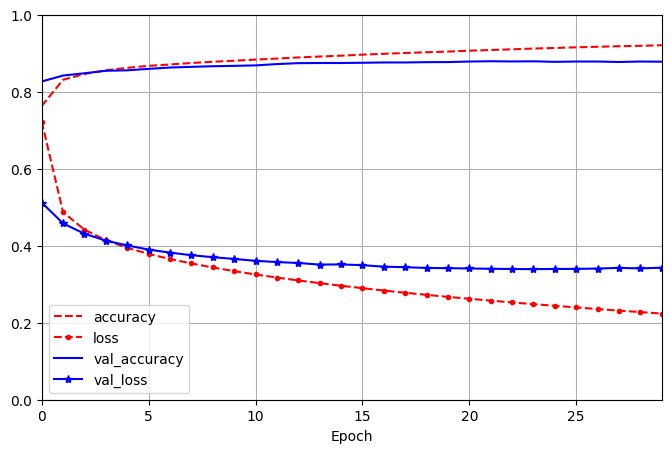

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 29], ylim=[0, 1], grid=True, xlabel="Epoch", style=["r--", "r--.", "b-", "b-*"]
)
plt.show()

In [40]:
model.evaluate(X_test, y_test)

311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 488us/step - accuracy: 0.8770 - loss: 0.3624

I0000 00:00:1719923996.009219   27503 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_36', 4 bytes spill stores, 4 bytes spill loads



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8770 - loss: 0.3623


[0.3585737645626068, 0.8776999711990356]

In [41]:
X_new = X_test[:3]
y_proba = model.predict(X_new)
y_proba.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 596ms/step


array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.14, 0.  , 0.02, 0.  , 0.84],
       [0.  , 0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]],
      dtype=float32)

In [43]:
import numpy as np
y_pred = y_proba.argmax(axis=-1)
y_pred

array([9, 2, 1])

In [44]:
np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

In [49]:
housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, random_state=42)

tf.random.set_seed(42)
norm_layer = tf.keras.layers.Normalization()
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=X_train.shape[1:]),
    norm_layer,
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu"),\
    tf.keras.layers.Dense(1)
])
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])
norm_layer.adapt(X_train)
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))
mse_test, rmse_test = model.evaluate(X_test, y_test)
X_new = X_test[:3]
y_pred = model.predict(X_new)

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - RootMeanSquaredError: 1.2540 - loss: 1.6947 - val_RootMeanSquaredError: 0.6094 - val_loss: 0.3714
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 635us/step - RootMeanSquaredError: 0.6262 - loss: 0.3925 - val_RootMeanSquaredError: 0.6579 - val_loss: 0.4328
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 572us/step - RootMeanSquaredError: 0.5932 - loss: 0.3520 - val_RootMeanSquaredError: 0.6139 - val_loss: 0.3769
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 529us/step - RootMeanSquaredError: 0.5782 - loss: 0.3345 - val_RootMeanSquaredError: 0.6265 - val_loss: 0.3925
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 559us/step - RootMeanSquaredError: 0.5665 - loss: 0.3210 - val_RootMeanSquaredError: 0.6380 - val_loss: 0.4071
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 639us/step - RootMeanSquaredError: 0.5599 - loss: 0.3137 - val_RootMeanSquaredError: 0.8686 - val_loss: 0.7544
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 670us/step - RootMeanSquaredError: 

In [50]:
normalization_layer = tf.keras.layers.Normalization()
hidden_layer1 = tf.keras.layers.Dense(30, activation="relu")
hidden_layer2 = tf.keras.layers.Dense(30, activation="relu")
concat_layer = tf.keras.layers.Concatenate()
output_layer = tf.keras.layers.Dense(1)

input_ = tf.keras.layers.Input(shape=X_train.shape[1:])
normalized = normalization_layer(input_)
hidden1 = hidden_layer1(normalized)
hidden2 = hidden_layer2(hidden1)
concat = concat_layer([normalized, hidden2])
output = output_layer(concat)

model = tf.keras.Model(inputs=[input_], outputs=[output])

In [51]:
input_wide = tf.keras.layers.Input(shape=[5])
input_deep = tf.keras.layers.Input(shape=[6])
norm_layer_wide = tf.keras.layers.Normalization()
norm_layer_deep = tf.keras.layers.Normalization()
norm_wide = norm_layer_wide(input_wide)
norm_deep = norm_layer_deep(input_deep)
hidden1 = tf.keras.layers.Dense(30, activation="relu")(norm_deep)
hidden2 = tf.keras.layers.Dense(30, activation="relu")(hidden1)
concat = tf.keras.layers.concatenate([norm_wide, hidden2])
output = tf.keras.layers.Dense(1)(concat)
model = tf.keras.Model(inputs=[input_wide, input_deep], outputs=[output])

In [53]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])

X_train_wide, X_train_deep = X_train[:, :5], X_train[:, 2:]
X_valid_wide, X_valid_deep = X_valid[:, :5], X_valid[:, 2:]
X_test_wide, X_test_deep = X_test[:, :5], X_test[:, 2:]
X_new_wide, X_new_deep = X_test_wide[:3], X_test_deep[:3]

norm_layer_wide.adapt(X_train_wide)
norm_layer_deep.adapt(X_train_deep)
history = model.fit((X_train_wide, X_train_deep), y_train, epochs=20, validation_data=((X_valid_wide, X_valid_deep), y_valid))
mse_test = model.evaluate((X_test_wide, X_test_deep), y_test)
y_pred = model.predict((X_new_wide, X_new_deep))
y_pred

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.6127 - loss: 0.3756 - val_RootMeanSquaredError: 0.7440 - val_loss: 0.5535
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 641us/step - RootMeanSquaredError: 0.5999 - loss: 0.3600 - val_RootMeanSquaredError: 0.7026 - val_loss: 0.4937
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 656us/step - RootMeanSquaredError: 0.5932 - loss: 0.3520 - val_RootMeanSquaredError: 1.0704 - val_loss: 1.1458
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 574us/step - RootMeanSquaredError: 0.5891 - loss: 0.3472 - val_RootMeanSquaredError: 1.3030 - val_loss: 1.6978
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 728us/step - RootMeanSquaredError: 0.5876 - loss: 0.3454 - val_RootMeanSquaredError: 1.6590 - val_loss: 2.7524
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 606us/step - RootMeanSquaredError: 0.5878 - loss: 0.3455 - val_RootMeanSquaredError: 1.5606 - val_loss: 2.4353
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 588us/step - RootMeanSquaredError: 

array([[0.47015196],
       [1.2694002 ],
       [3.6436942 ]], dtype=float32)

In [55]:
input_wide = tf.keras.layers.Input(shape=[5])
input_deep = tf.keras.layers.Input(shape=[6])
norm_layer_wide = tf.keras.layers.Normalization()
norm_layer_deep = tf.keras.layers.Normalization()
norm_wide = norm_layer_wide(input_wide)
norm_deep = norm_layer_deep(input_deep)
hidden1 = tf.keras.layers.Dense(30, activation="relu")(norm_deep)
hidden2 = tf.keras.layers.Dense(30, activation="relu")(hidden1)
concat = tf.keras.layers.concatenate([norm_wide, hidden2])
output = tf.keras.layers.Dense(1)(concat)
aux_output = tf.keras.layers.Dense(1)(hidden2)
model = tf.keras.Model(inputs=[input_wide, input_deep], outputs=[output, aux_output])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss=("mse", "mse"), loss_weights=(0.9, 0.1), optimizer=optimizer, metrics=["RootMeanSquaredError", "RootMeanSquaredError"])

X_train_wide, X_train_deep = X_train[:, :5], X_train[:, 2:]
X_valid_wide, X_valid_deep = X_valid[:, :5], X_valid[:, 2:]
X_test_wide, X_test_deep = X_test[:, :5], X_test[:, 2:]
X_new_wide, X_new_deep = X_test_wide[:3], X_test_deep[:3]

norm_layer_wide.adapt(X_train_wide)
norm_layer_deep.adapt(X_train_deep)
history = model.fit((X_train_wide, X_train_deep), (y_train, y_train), epochs=20, validation_data=((X_valid_wide, X_valid_deep), (y_valid, y_valid)))
mse_test = model.evaluate((X_test_wide, X_test_deep), (y_test, y_test))
y_pred = model.predict((X_new_wide, X_new_deep))
y_pred

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - dense_33_RootMeanSquaredError: 1.7015 - dense_34_RootMeanSquaredError: 1.8646 - loss: 3.0565 - val_dense_33_RootMeanSquaredError: 1.8895 - val_dense_34_RootMeanSquaredError: 1.8651 - val_loss: 3.5611
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 785us/step - dense_33_RootMeanSquaredError: 0.8615 - dense_34_RootMeanSquaredError: 0.8559 - loss: 0.7421 - val_dense_33_RootMeanSquaredError: 1.1430 - val_dense_34_RootMeanSquaredError: 1.4188 - val_loss: 1.3770
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 868us/step - dense_33_RootMeanSquaredError: 0.7507 - dense_34_RootMeanSquaredError: 0.7673 - loss: 0.5664 - val_dense_33_RootMeanSquaredError: 0.7650 - val_dense_34_RootMeanSquaredError: 1.0975 - val_loss: 0.6471
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 762us/step - dense_33_RootMeanSquaredError: 0.6932 - dense_34_RootMeanSquaredError: 0.7346 - loss: 0.4867 - val_dense_33_RootMeanSquaredError: 0.6602 - val_dense_34_RootMeanSquaredError: 0.92

[array([[0.3384567],
        [1.2434702],
        [3.4942958]], dtype=float32),
 array([[0.40943766],
        [1.2071586 ],
        [3.326372  ]], dtype=float32)]

In [58]:
class WideAndDeepModel(tf.keras.Model):
    def __init__(self, units=30, activation="relu", **kwargs):
        super().__init__(**kwargs)
        self.norm_layer_wide = tf.keras.layers.Normalization()
        self.norm_layer_deep = tf.keras.layers.Normalization()
        self.hidden1 = tf.keras.layers.Dense(units, activation=activation)
        self.hidden2 = tf.keras.layers.Dense(units, activation=activation)
        self.main_output = tf.keras.layers.Dense(1)
        self.aux_output = tf.keras.layers.Dense(1)

    def call(self, inputs):
        input_wide, input_deep = inputs
        norm_wide = self.norm_layer_wide(input_wide)
        norm_deep = self.norm_layer_deep(input_deep)
        hidden1 = self.hidden1(norm_deep)
        hidden2 = self.hidden2(hidden1)
        concat = tf.keras.layers.concatenate([norm_wide, hidden2])
        output = self.main_output(concat)
        aux_output = self.aux_output(hidden2)
        return output, aux_output

model = WideAndDeepModel(30, activation="relu", name="my_cool_model")
        